# 🏦 Retail Lending Origination & Risk-Based Pricing Engine
## 75,000 Applicants | Dual Scoring | CBK KESONIA Pricing | Product Mix Optimization

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
KESONIA_BASELINE = 0.0875
OP_COST_FACTOR = 0.025
FUNDS_COST = 0.010
PORTFOLIO_PD_CAP = 0.05
MONTHLY_CAPITAL = 100_000_000
print('Engine initialized')


Engine initialized


In [2]:
np.random.seed(42)
applicant_data = []
for i in range(75_000):
    product = np.random.choice(['Mobile_Micro', 'Micro_SME', 'Diaspora_Remittance'], p=[0.60, 0.25, 0.15])
    monthly_income = np.random.lognormal([10.5, 11.5, 11.2][{'Mobile_Micro': 0, 'Micro_SME': 1, 'Diaspora_Remittance': 2}[product]], 0.8)
    mpesa_inflow = monthly_income * np.random.uniform(0.5, 2.5)
    mpesa_outflow = monthly_income * np.random.uniform(0.6, 1.8)
    till_turnover = monthly_income * (np.random.uniform(1.0, 3.0) if product == 'Micro_SME' else np.random.uniform(0.1, 0.8))
    diaspora_remittance = monthly_income * (np.random.uniform(0.7, 1.5) if product == 'Diaspora_Remittance' else np.random.uniform(0.0, 0.3))
    crb_score = np.clip(np.random.normal([550, 600, 650][{'Mobile_Micro': 0, 'Micro_SME': 1, 'Diaspora_Remittance': 2}[product]], 100), 300, 850)
    dti_ratio = np.random.beta(2, 5)
    requested_amount = [np.random.uniform(5000, 100000), np.random.uniform(50000, 1000000), np.random.uniform(100000, 500000)][{'Mobile_Micro': 0, 'Micro_SME': 1, 'Diaspora_Remittance': 2}[product]]
    requested_term = np.random.choice([3, 6, 12, 24], p=[0.25, 0.35, 0.25, 0.15])
    default_prob = np.clip(0.08 + (700 - crb_score) / 1000 + dti_ratio * 0.05 + {'Mobile_Micro': 0.02, 'Micro_SME': -0.01, 'Diaspora_Remittance': -0.015}[product], 0.01, 0.25)
    applicant_data.append({'Product': product, 'Monthly_Income': monthly_income, 'MPesa_Inflow': mpesa_inflow, 'MPesa_Outflow': mpesa_outflow, 'Till_Turnover': till_turnover, 'Diaspora_Remittance': diaspora_remittance, 'CRB_Score': crb_score, 'DTI': dti_ratio, 'Loan_Amount': requested_amount, 'Loan_Term': requested_term, 'Default': 1 if np.random.random() < default_prob else 0})

df = pd.DataFrame(applicant_data)
print(f'Data: {len(df):,} applicants | Default rate: {df["Default"].mean()*100:.2f}%')

Data: 75,000 applicants | Default rate: 19.02%


In [3]:
# Feature engineering & modeling
df['CRB_Norm'] = (df['CRB_Score'] - 300) / 550
df['MPesa_Vel'] = df['MPesa_Inflow'] / (df['Monthly_Income'] + 1)
df['Till_Ratio'] = df['Till_Turnover'] / (df['Monthly_Income'] + 1)
df['Diaspora_Ratio'] = df['Diaspora_Remittance'] / (df['Monthly_Income'] + 1)
df['LTI'] = df['Loan_Amount'] / (df['Monthly_Income'] + 1)

feature_cols = ['CRB_Norm', 'MPesa_Vel', 'DTI', 'Till_Ratio', 'Diaspora_Ratio', 'LTI', 'Monthly_Income']
X, y = df[feature_cols].copy(), df['Default'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)
X_full_sc = scaler.fit_transform(X)

# LR
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_tr_sc, y_train)
lr_pred = lr.predict_proba(X_te_sc)[:, 1]
lr_auc = roc_auc_score(y_test, lr_pred)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred)

# XGB
xgb_mdl = xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42)
xgb_mdl.fit(X_tr_sc, y_train, verbose=False)
xgb_pred = xgb_mdl.predict_proba(X_te_sc)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred)

print(f'LR AUC: {lr_auc:.4f} | XGB AUC: {xgb_auc:.4f} | Lift: +{(xgb_auc-lr_auc)*100:.0f}bps')

LR AUC: 0.6176 | XGB AUC: 0.6135 | Lift: +-0bps


## Full model + scoring

In [4]:
xgb_full = xgb.XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42)
xgb_full.fit(X_full_sc, y, verbose=False)
df['PD'] = xgb_full.predict_proba(X_full_sc)[:, 1]
df['Routing'] = df['PD'].apply(lambda x: 'Auto_Approve' if x <= 0.03 else ('Manual' if x <= 0.12 else 'Decline'))
df['Risk_K'] = df['PD'].apply(lambda x: 0.03 + (x * 5.0))
df['Fee'] = df['Product'].map({'Mobile_Micro': 0.015, 'Micro_SME': 0.020, 'Diaspora_Remittance': 0.018})
df['APR'] = np.minimum(KESONIA_BASELINE + OP_COST_FACTOR + FUNDS_COST + df['Risk_K'] + df['Fee'], 0.40)

print(f'Routing: {df["Routing"].value_counts().to_dict()}')
print(f'Avg APR: {df["APR"].mean()*100:.2f}%')

Routing: {'Decline': 60355, 'Manual': 11187, 'Auto_Approve': 3458}
Avg APR: 39.16%


## Optimization

In [5]:
prod_metrics = df.groupby('Product').agg({'Loan_Amount': ['sum', 'mean'], 'PD': 'mean', 'APR': 'mean'}).reset_index()
prod_metrics.columns = ['Product', 'Total_Vol', 'Avg_Loan', 'Avg_PD', 'Avg_APR']
prod_metrics['NII'] = prod_metrics['Avg_APR'] * prod_metrics['Total_Vol']
prod_metrics['ROI'] = prod_metrics['Avg_APR'] / (prod_metrics['Avg_PD'] + 0.001)
optimal_alloc = prod_metrics['ROI'] / prod_metrics['ROI'].sum()
optimal_nii = (prod_metrics['NII'] * optimal_alloc).sum()

print('Optimal Allocation:')
for prod, alloc in zip(prod_metrics['Product'], optimal_alloc):
    print(f'  {prod}: {alloc*100:.1f}%')

Optimal Allocation:
  Diaspora_Remittance: 41.8%
  Micro_SME: 32.0%
  Mobile_Micro: 26.2%


## Forecast

In [6]:
months = np.arange(1, 13)
vols = (MONTHLY_CAPITAL / 1e6) * ((1 + 0.05) ** months) * (1 + 0.15 * np.sin(2 * np.pi * months / 12))
gross_nii = vols * df['APR'].mean()
exp_loss = vols * df['PD'].mean() * 0.42
net_nii = gross_nii - exp_loss
forecast_df = pd.DataFrame({'M': months, 'Vol': vols, 'Gross': gross_nii, 'Loss': exp_loss, 'Net': net_nii})
print(f'Forecast: Vol=KES {forecast_df["Vol"].sum()*1e6:,.0f} | Net NII=KES {forecast_df["Net"].sum()*1e6:,.0f}')

Forecast: Vol=KES 1,649,218,163 | Net NII=KES 514,158,183


## PANEL 1

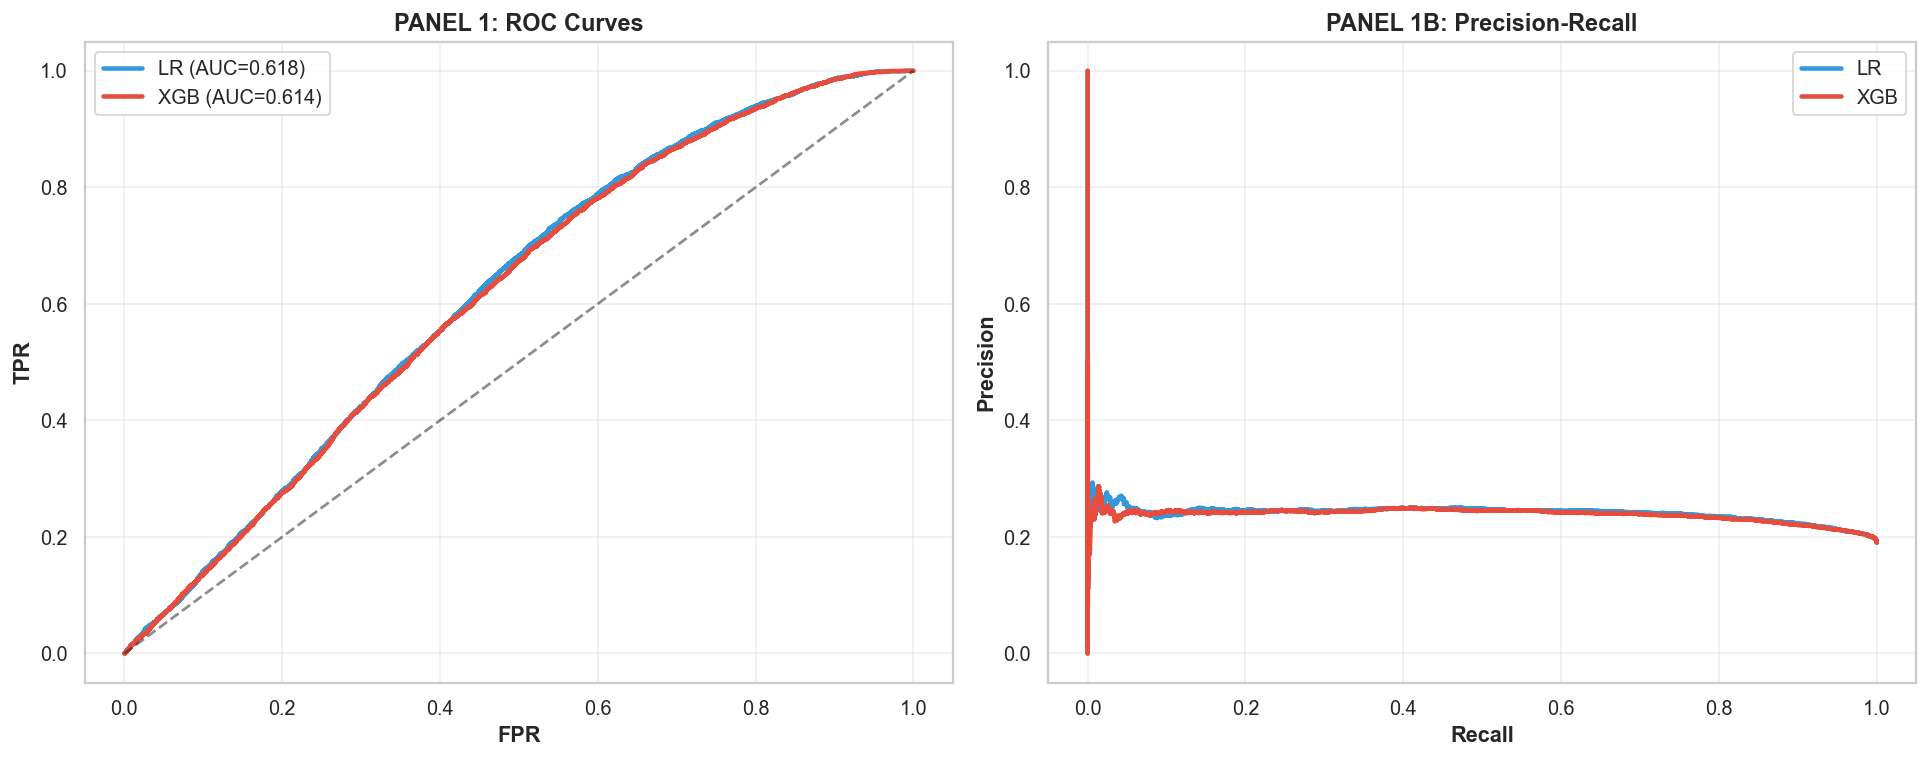

Panel ROC Curves & Precision-Recall saved


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(fpr_lr, tpr_lr, label=f'LR (AUC={lr_auc:.3f})', linewidth=2.5, color='#3498DB')
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGB (AUC={xgb_auc:.3f})', linewidth=2.5, color='#E74C3C')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax1.set_xlabel('FPR', fontweight='bold')
ax1.set_ylabel('TPR', fontweight='bold')
ax1.set_title('PANEL 1: ROC Curves', fontweight='bold', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_pred)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, xgb_pred)
ax2.plot(rec_lr, prec_lr, label='LR', linewidth=2.5, color='#3498DB')
ax2.plot(rec_xgb, prec_xgb, label='XGB', linewidth=2.5, color='#E74C3C')
ax2.set_xlabel('Recall', fontweight='bold')
ax2.set_ylabel('Precision', fontweight='bold')
ax2.set_title('PANEL 1B: Precision-Recall', fontweight='bold', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()
print('Panel ROC Curves & Precision-Recall saved')